In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
data1 = pd.read_csv(r"C:\Users\varia\OneDrive\Dragon Hoard's Index\Datasets\Cleaned Datasets\PCGS3000 Index Monthly 2024 Fixed.xls")
#data['Date'] = pd.to_datetime(data['Date'])
#df1 = data.set_index('Date')

data2 = pd.read_csv(r"C:\Users\varia\OneDrive\Dragon Hoard's Index\Datasets\PCGS3000 2024-2026.csv")
data2 = data2[94:]
#data2['Date'] = pd.to_datetime(data2['Date'])
#df2 = data2.set_index('Date')

In [24]:
data2.iloc[0]

Date     2024-12-10
Price      73019.15
Name: 94, dtype: object

In [28]:
data2.tail()

,Date,Price
184,2025-12-23,73159.41
185,2025-12-30,73124.99
186,2026-01-01,73153.12
187,2026-01-04,73098.19
188,2026-01-06,73078.45


In [39]:
data1.head()

,Unnamed: 0,Price
0,1970-02-01,1024.24
1,1970-03-01,1024.24
2,1970-04-01,1024.24
3,1970-05-01,1024.24
4,1970-06-01,1024.24


In [43]:
data1 = data1.rename(columns = {'Unnamed: 0':'Date'})

In [44]:
data = pd.concat([data1,data2])

In [46]:
data.tail()

,Date,Price
184,2025-12-23,73159.41
185,2025-12-30,73124.99
186,2026-01-01,73153.12
187,2026-01-04,73098.19
188,2026-01-06,73078.45


In [47]:
data['Date'] = pd.to_datetime(data['Date'])
df = data.set_index('Date')

In [48]:
monthly_dates = pd.date_range(start = df.index.min(), end = df.index.max(), freq = "MS")
df = df.groupby(df.index).mean()

In [50]:
df.tail()

,Price
Date,
2025-12-23,73159.41
2025-12-30,73124.99
2026-01-01,73153.12
2026-01-04,73098.19
2026-01-06,73078.45


In [51]:
df = df.reindex(df.index.union(monthly_dates)).sort_index()

df['Price'] = df['Price'].interpolate(method = 'time')

In [52]:
monthly_df = df.loc[monthly_dates] # WANT THIS IN CSV FINAL DATASET CONVERTED

In [54]:
monthly_df.head()

,Price
1970-02-01,1024.24
1970-03-01,1024.24
1970-04-01,1024.24
1970-05-01,1024.24
1970-06-01,1024.24


In [55]:
print(monthly_dates)

DatetimeIndex(['1970-02-01', '1970-03-01', '1970-04-01', '1970-05-01',
               '1970-06-01', '1970-07-01', '1970-08-01', '1970-09-01',
               '1970-10-01', '1970-11-01',
               ...
               '2025-04-01', '2025-05-01', '2025-06-01', '2025-07-01',
               '2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01',
               '2025-12-01', '2026-01-01'],
              dtype='datetime64[ns]', length=672, freq='MS')


In [56]:
print(type(monthly_df))

<class 'pandas.core.frame.DataFrame'>


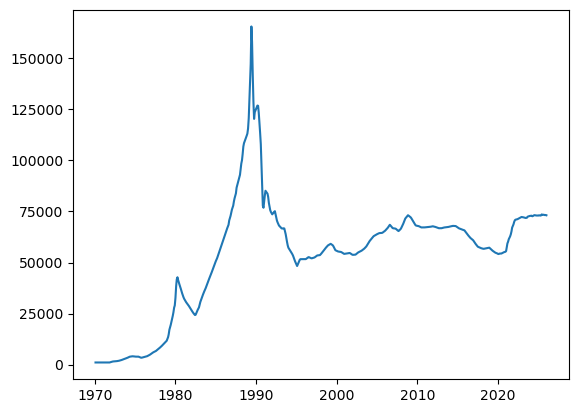

In [57]:
plt.plot(monthly_df)
plt.show()

In [58]:
monthly_df = monthly_df.round(2)

In [59]:
monthly_df.to_csv("PCGS3000 Index Monthly 2026 Fixed.csv")